<a href="https://colab.research.google.com/github/reighrey19/shiara_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [1]:
%pip install pandas mlxtend matplotlib networkx

from google.colab import files
uploaded = files.upload()


Saving bread_basket.csv to bread_basket.csv


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [2]:
import pandas as pd
df = pd.read_csv("bread_basket.csv")
print(df.dtypes)
df.head()

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [3]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

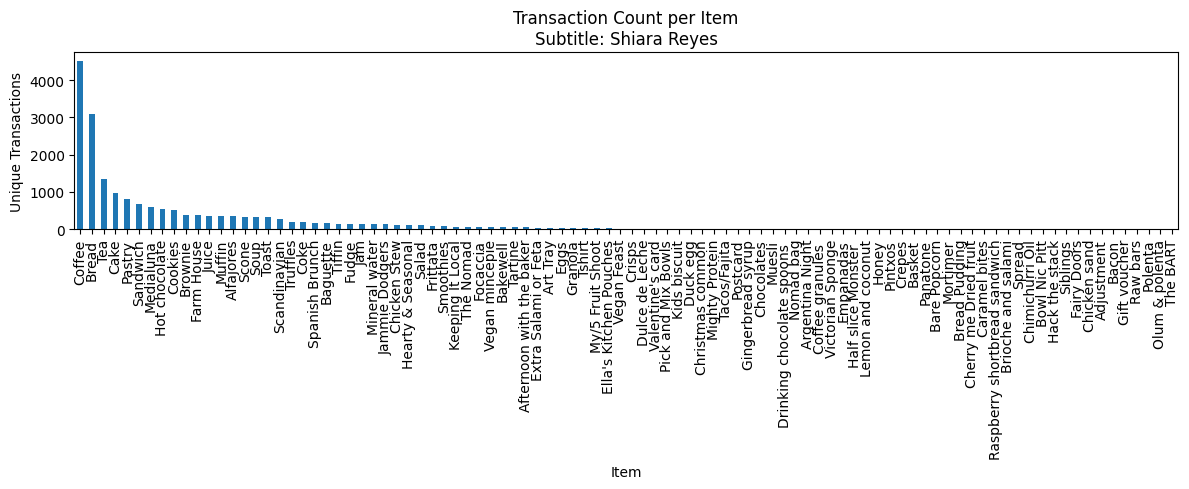

In [4]:
# c) Bar plot of transaction counts per item
subtitle = "Shiara Reyes"  # <-- EDIT THIS
item_counts = df.groupby('item')['transaction'].nunique().sort_values(ascending=False)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [5]:
df = pd.read_csv("bread_basket.csv")
items_to_count = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
item_counts = df[df['item'].isin(items_to_count)].groupby('item')['transaction'].nunique()

print(item_counts)

item
Alfajores        344
Chicken Stew     123
Coffee          4528
Juice            365
Tea             1350
Name: transaction, dtype: int64


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [19]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [21]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
# Group items by transaction to create a list of lists for TransactionEncoder
transactions = df.groupby('transaction')['item'].apply(list)
te_ary = te.fit(transactions).transform(transactions)
oht = pd.DataFrame(te_ary, columns=te.columns_).astype(bool)
oht.head()



,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(oht, min_support=0.2, use_colnames=True)

print("Frequent Itemsets:")
display(frequent_itemsets)


Frequent Itemsets:


,support,itemsets
0,0.327205,(Bread)
1,0.478394,(Coffee)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [29]:
from mlxtend.frequent_patterns import apriori, association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.01)

rules.sort_values(by='lift', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

The rule {Coffee, Cake} ⇒ {Bread} means that transactions containing coffee and cake together are likely to have bread included.

With a min_support of 0.2 I did not find enough transactions to answer this questions properly. However, support would explain the frequency for these 3 items to appear in a transaction together.

Confidence is the rule that explains how likely bread is to be included in a transaction that has coffee and cake.

Lift > 1 means that bread is more likely to be bought in transactions that include coffee and cake.

>